# Assignment I — Portfolio Optimization
### Modern Portfolio Theory | NSE 30-Stock Universe → 10-Stock Portfolio
**Objective:** Select 10 stocks, run Monte Carlo simulation (≥10,000 iterations), and identify the  
Global Minimum Variance (GMV) and Maximum Sharpe Ratio (MSR) portfolios.  
**Risk-Free Rate:** 6.5% | **Long-Only Constraint** | **Annualisation Factor:** 252 trading days

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [2]:
price_df = pd.read_csv("daily_returns.csv", parse_dates=["Date"], index_col="Date") # returns are % returns
meta_df  = pd.read_csv("stock_categories.csv")

STOCKS = meta_df["Symbol"].tolist()
TRADING_DAYS = 252
RF = 6.5   # Risk-free rate: 6.5%

print(f"Returns data : {price_df.shape[0]} trading days x {price_df.shape[1]} columns")
print(f"Stock meta   : {len(STOCKS)} stocks across {meta_df['Category'].nunique()} sectors")
print(f"Date range   : {price_df.index.min().date()} → {price_df.index.max().date()}")
print(f"\nNull values  : {price_df[STOCKS].isna().sum().sum()}")

Returns data : 739 trading days x 32 columns
Stock meta   : 30 stocks across 10 sectors
Date range   : 2023-02-02 → 2026-01-30

Null values  : 0


## 2. EDA — Sector Distribution & Return Overview

In [3]:
# Annualised metrics for all 30 stocks
mean_d = price_df[STOCKS].mean()
std_d  = price_df[STOCKS].std()

metrics_df = pd.DataFrame({
    "ann_return": mean_d * TRADING_DAYS,
    "ann_vol"   : std_d  * np.sqrt(TRADING_DAYS),
}, index=mean_d.index)
metrics_df["sharpe"] = (metrics_df["ann_return"] - RF) / metrics_df["ann_vol"]
metrics_df = metrics_df.merge(
    meta_df.set_index("Symbol")[["Category","Company Name"]],
    left_index=True, right_index=True
)

print("All 30 stocks — annualised metrics (sorted by Sharpe):")
metrics_df.sort_values("sharpe", ascending=False)[
    ["Company Name","Category","ann_return","ann_vol","sharpe"]
].round(4)

All 30 stocks — annualised metrics (sorted by Sharpe):


,Company Name,Category,ann_return,ann_vol,sharpe
BHARTIARTL,Bharti Airtel,Telecommunications,34.7123,20.0836,1.4047
BAJAJ-AUTO,Bajaj Auto,Automobiles,36.6700,24.4483,1.2340
TRENT,Trent,Retail/E-commerce,44.9458,34.9990,1.0985
M&M,Mahindra & Mahindra,Automobiles,36.4056,27.4152,1.0908
INDUSTOWER,Indus Towers,Telecommunications,44.7316,35.6920,1.0712
ADANIPORTS,Adani Ports,Construction/Infra,42.9412,35.7514,1.0193
NTPC,NTPC,Energy & Power,31.8753,25.4509,0.9970
SBIN,State Bank of India,Banking & Finance,28.8830,22.7735,0.9828
HINDALCO,Hindalco,Metals & Mining,29.3505,28.4199,0.8040
LT,Larsen & Toubro,Construction/Infra,24.3782,23.3382,0.7660


## 3. Stock Selection: 30 → 10

### Method 1:

**Methodology:**  
- Ranked all stocks *within each sector* by annualised Sharpe ratio.  
- Selected the **top-ranked stock per sector** — ensures:  
  1. Broad sector diversification (one representative per sector)  
  2. Best risk-adjusted performance within the sector  
- Validated with a cross-sector correlation heatmap (low off-diagonal values confirm diversification).

In [7]:
# Select best Sharpe per sector
selected1 = (
    metrics_df
    .sort_values("sharpe", ascending=False)
    .groupby("Category")
    .head(1)
)
selected_symbols1 = selected1.index.tolist()

print("Selected Universe (10 Stocks):")
print("=" * 65)
print(selected1[["Company Name","Category","ann_return","ann_vol","sharpe"]]
      .rename(columns={"ann_return":"Ann.Return","ann_vol":"Ann.Vol","sharpe":"Sharpe"})
      .round(4).to_string())
print("=" * 65)

Selected Universe (10 Stocks):
                   Company Name            Category  Ann.Return  Ann.Vol  Sharpe
BHARTIARTL        Bharti Airtel  Telecommunications     34.7123  20.0836  1.4047
BAJAJ-AUTO           Bajaj Auto         Automobiles     36.6700  24.4483  1.2340
TRENT                     Trent   Retail/E-commerce     44.9458  34.9990  1.0985
ADANIPORTS          Adani Ports  Construction/Infra     42.9412  35.7514  1.0193
NTPC                       NTPC      Energy & Power     31.8753  25.4509  0.9970
SBIN        State Bank of India   Banking & Finance     28.8830  22.7735  0.9828
HINDALCO               Hindalco     Metals & Mining     29.3505  28.4199  0.8040
SUNPHARMA            Sun Pharma     Pharmaceuticals     18.1374  18.5285  0.6281
HCLTECH                HCL Tech    Information Tech     20.3010  22.8543  0.6039
NESTLEIND          Nestlé India      Consumer Goods     14.0823  18.6451  0.4067


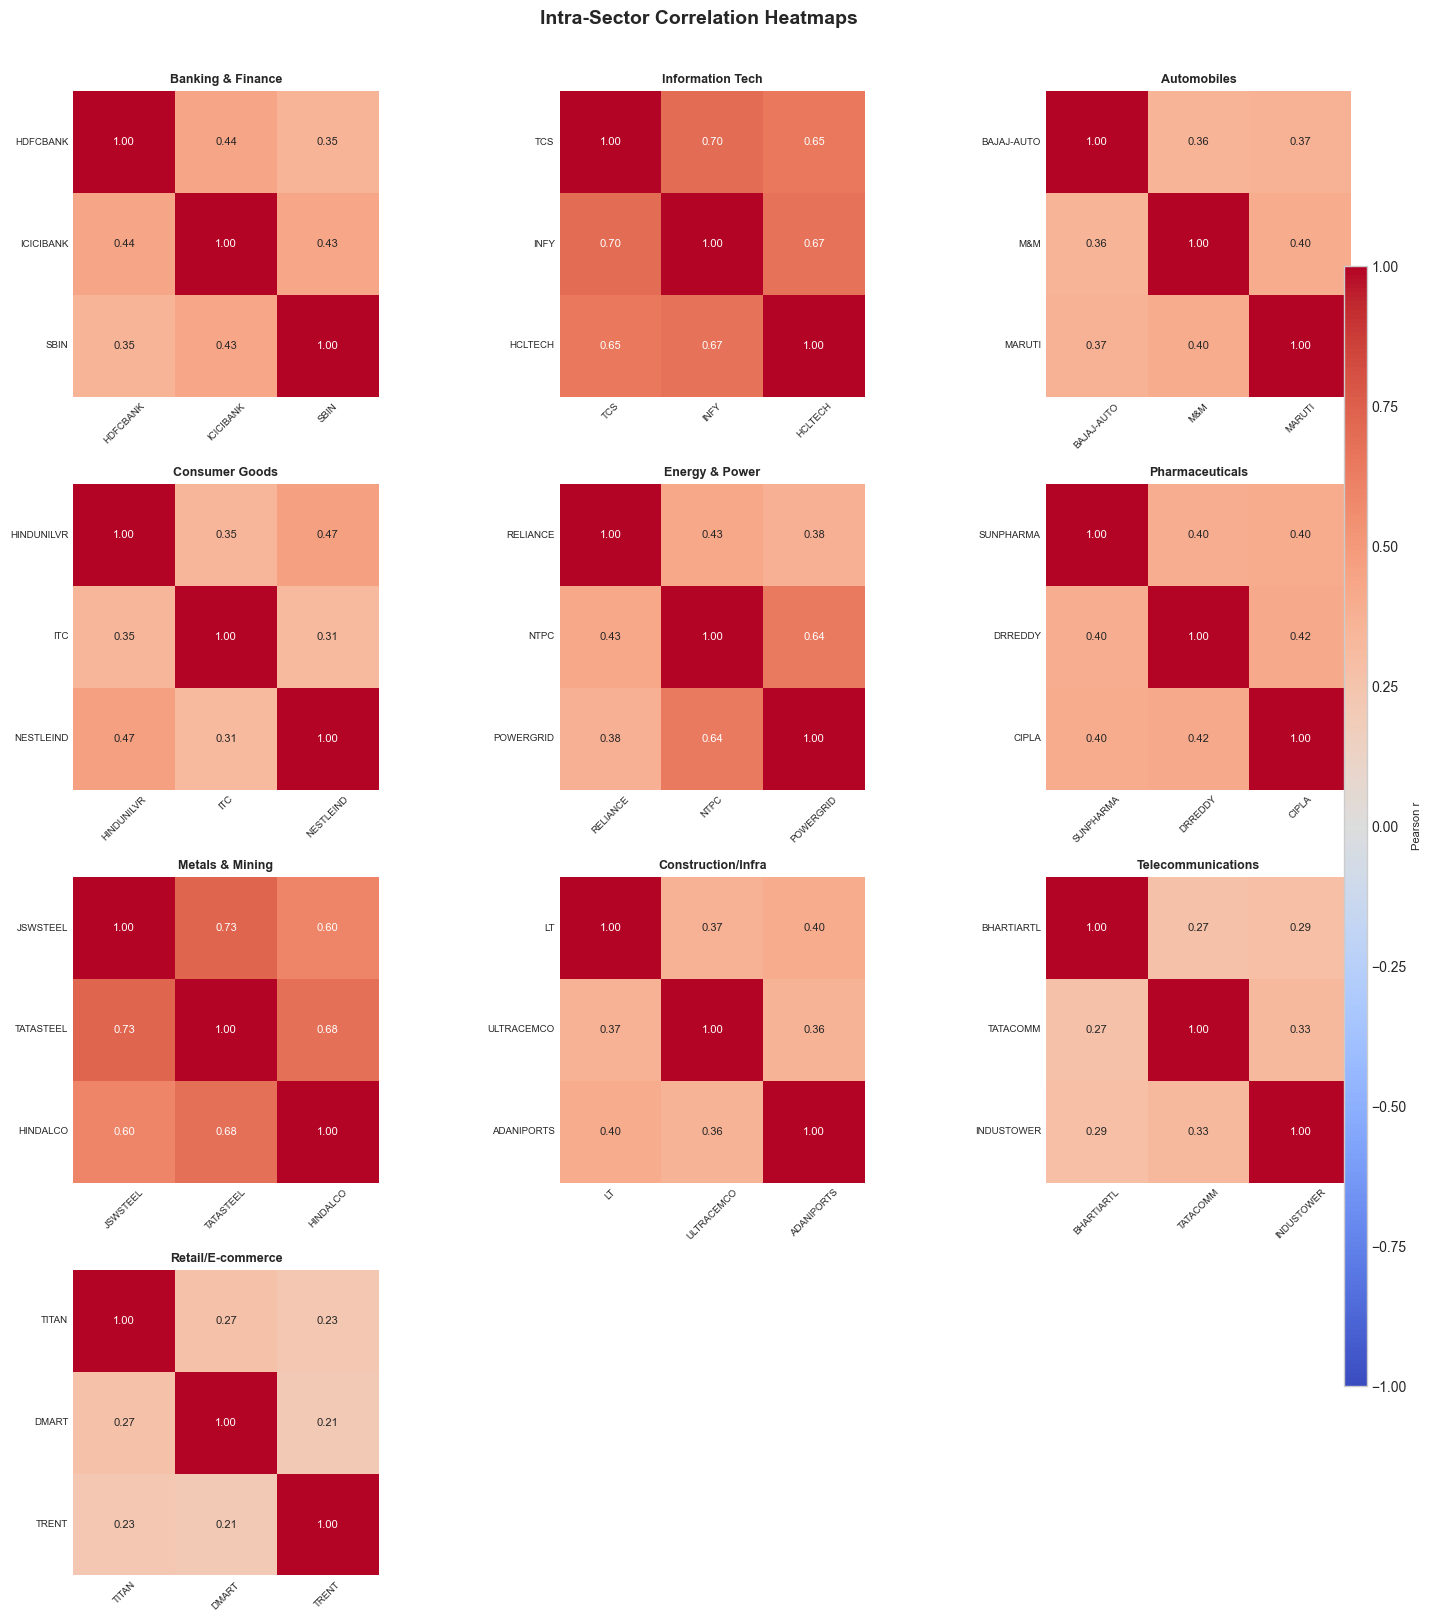

In [8]:
# Sector-wise correlation heatmaps (justification for selection)
import math
sectors = meta_df["Category"].unique()
n_cols, n_rows = 3, math.ceil(len(sectors)/3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()
hm = None
for i, sector in enumerate(sectors):
    syms = meta_df.loc[meta_df["Category"]==sector, "Symbol"].tolist()
    corr = price_df[syms].corr()
    hm = sns.heatmap(corr, ax=axes[i], cmap="coolwarm", center=0, vmin=-1, vmax=1,
                     square=True, cbar=False, annot=True, fmt=".2f", annot_kws={"size":8})
    axes[i].set_title(sector, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', rotation=0,  labelsize=7)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(hm.collections[0], cax=cbar_ax).set_label("Pearson r", fontsize=8)
fig.suptitle("Intra-Sector Correlation Heatmaps", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

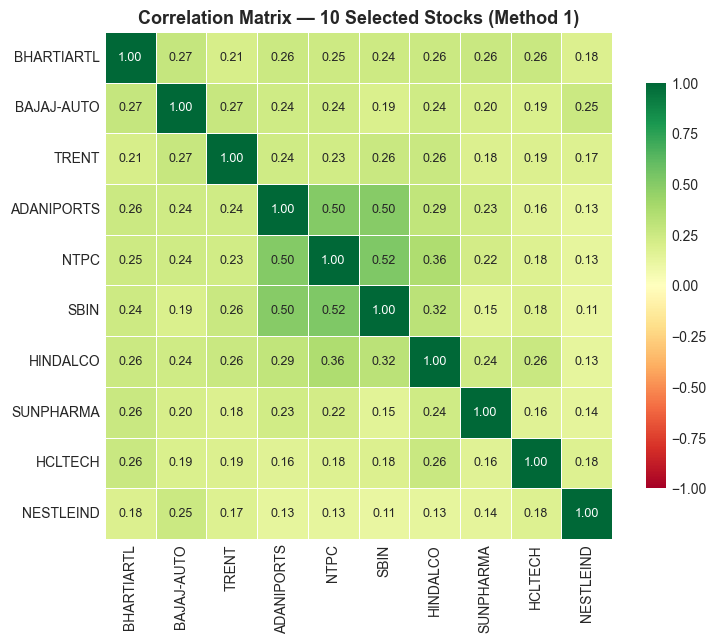

In [9]:
returns1 = price_df[selected_symbols1]
corr_10_1 = returns1.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_10_1, ax=ax, cmap="RdYlGn", vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size":9},
            square=True, linewidths=0.5, cbar_kws={"shrink":0.8})
ax.set_title("Correlation Matrix — 10 Selected Stocks (Method 1)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Method 2: 

**Methodology:**  
- Ranked all stocks by annualised Sharpe ratio.  
- Selected the **top 10 stocks globally** based on Sharpe ratio (irrespective of sector).  
- Validated with a cross-sector correlation heatmap (low off-diagonal values confirm diversification).

In [10]:
# Select best Sharpe per sector
selected2 = metrics_df.sort_values("sharpe", ascending=False).iloc[:10, :]
selected_symbols2 = selected2.index.tolist()

print("Selected Universe (10 Stocks):")
print("=" * 65)
print(selected2[["Company Name","Category","ann_return","ann_vol","sharpe"]]
      .rename(columns={"ann_return":"Ann.Return","ann_vol":"Ann.Vol","sharpe":"Sharpe"})
      .round(4).to_string())
print("=" * 65)

Selected Universe (10 Stocks):
                   Company Name            Category  Ann.Return  Ann.Vol  Sharpe
BHARTIARTL        Bharti Airtel  Telecommunications     34.7123  20.0836  1.4047
BAJAJ-AUTO           Bajaj Auto         Automobiles     36.6700  24.4483  1.2340
TRENT                     Trent   Retail/E-commerce     44.9458  34.9990  1.0985
M&M         Mahindra & Mahindra         Automobiles     36.4056  27.4152  1.0908
INDUSTOWER         Indus Towers  Telecommunications     44.7316  35.6920  1.0712
ADANIPORTS          Adani Ports  Construction/Infra     42.9412  35.7514  1.0193
NTPC                       NTPC      Energy & Power     31.8753  25.4509  0.9970
SBIN        State Bank of India   Banking & Finance     28.8830  22.7735  0.9828
HINDALCO               Hindalco     Metals & Mining     29.3505  28.4199  0.8040
LT              Larsen & Toubro  Construction/Infra     24.3782  23.3382  0.7660


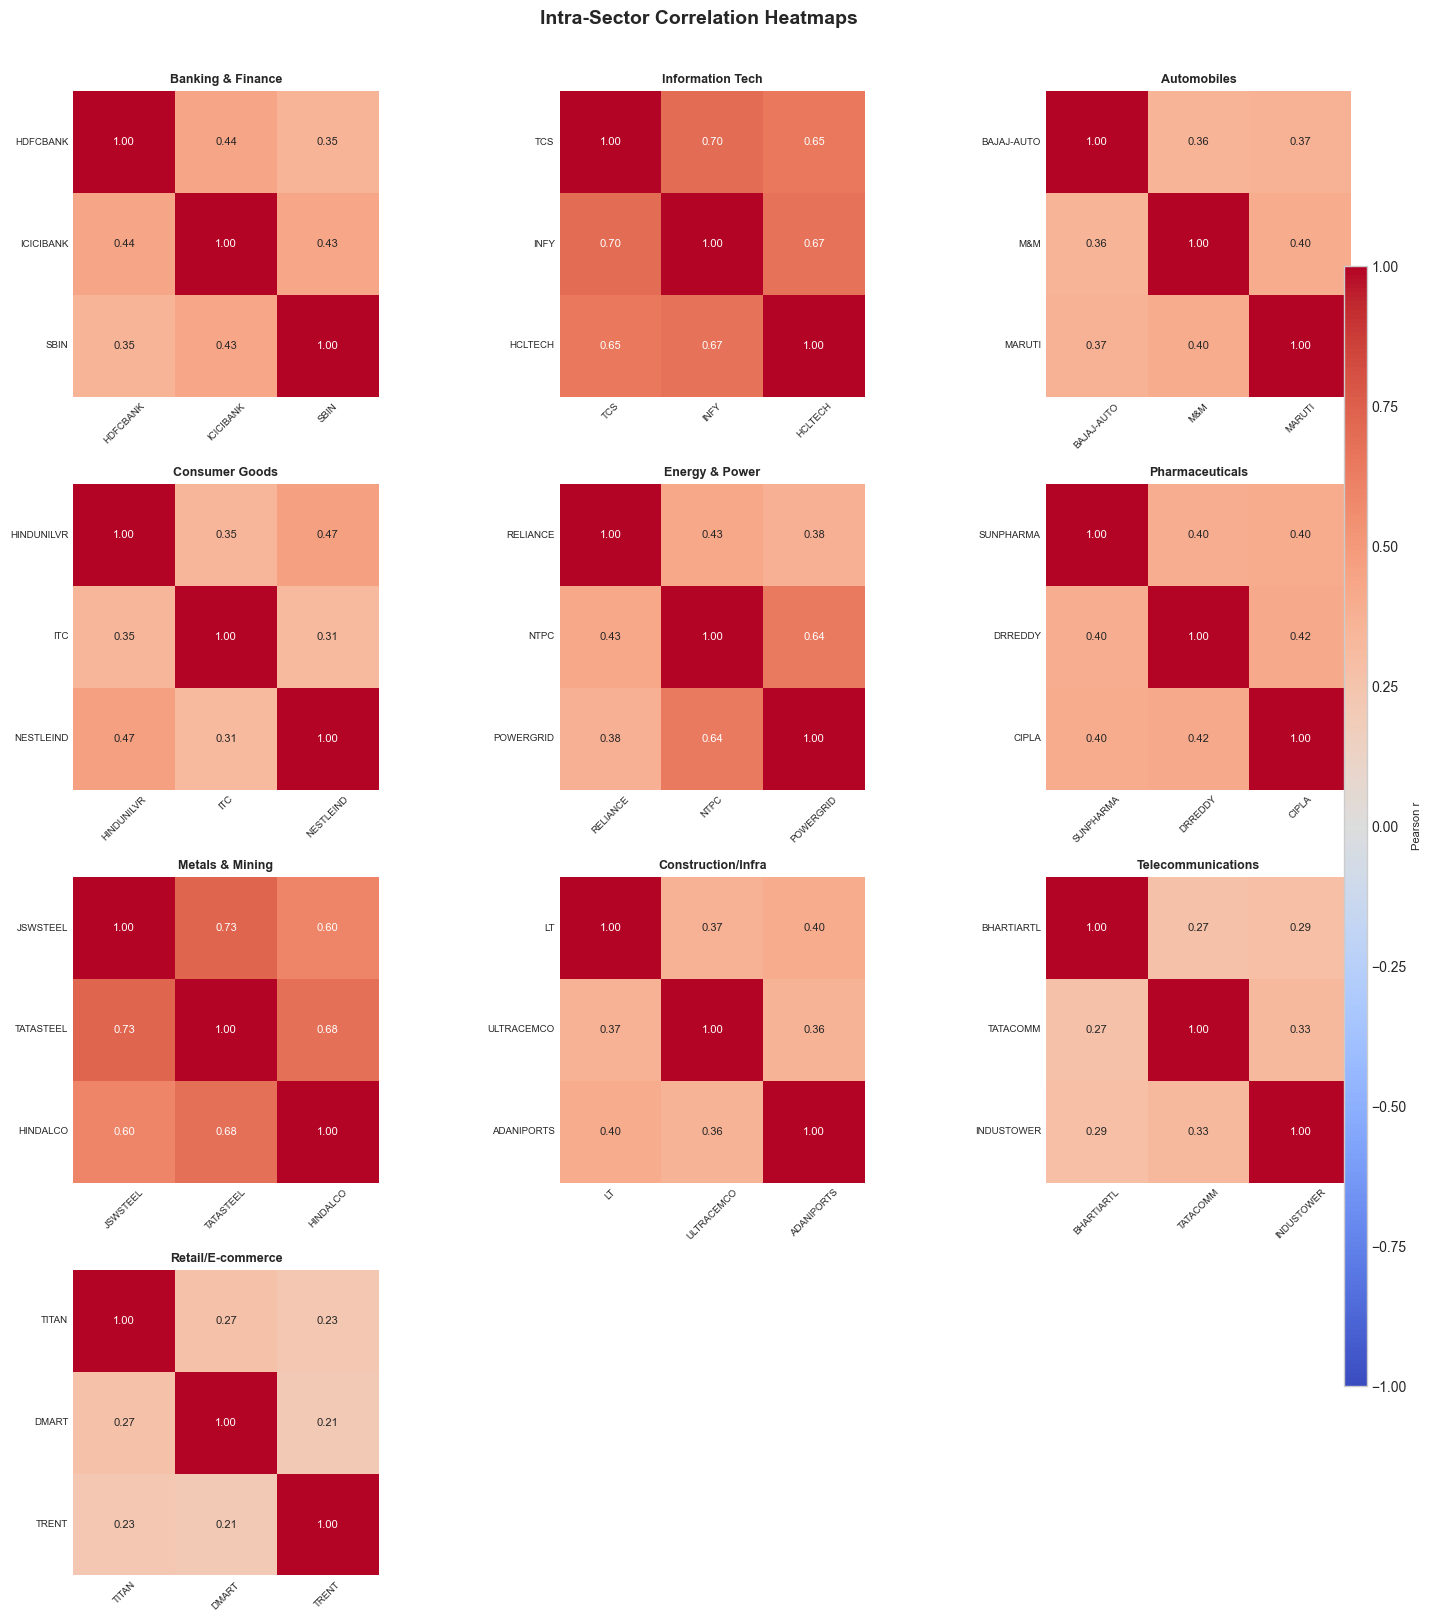

In [11]:
# Sector-wise correlation heatmaps (justification for selection)
import math
sectors = meta_df["Category"].unique()
n_cols, n_rows = 3, math.ceil(len(sectors)/3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()
hm = None
for i, sector in enumerate(sectors):
    syms = meta_df.loc[meta_df["Category"]==sector, "Symbol"].tolist()
    corr = price_df[syms].corr()
    hm = sns.heatmap(corr, ax=axes[i], cmap="coolwarm", center=0, vmin=-1, vmax=1,
                     square=True, cbar=False, annot=True, fmt=".2f", annot_kws={"size":8})
    axes[i].set_title(sector, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', rotation=0,  labelsize=7)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(hm.collections[0], cax=cbar_ax).set_label("Pearson r", fontsize=8)
fig.suptitle("Intra-Sector Correlation Heatmaps", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

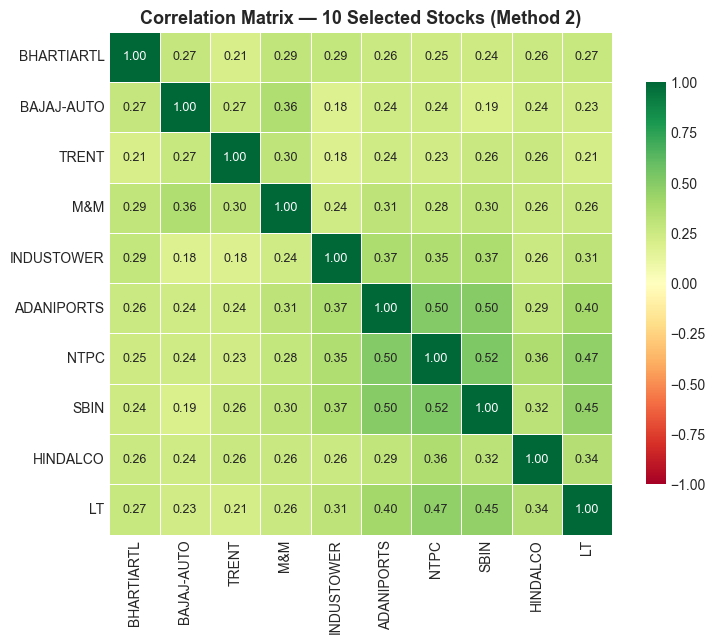

In [12]:
# Cross-sector correlation matrix — selected 10 stocks
returns2 = price_df[selected_symbols2]
corr_10_2 = returns2.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_10_2, ax=ax, cmap="RdYlGn", vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size":9},
            square=True, linewidths=0.5, cbar_kws={"shrink":0.8})
ax.set_title("Correlation Matrix — 10 Selected Stocks (Method 2)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Portfolio Optimization Setup

### Method 1:

In [15]:
mu1 = returns1.mean() * TRADING_DAYS      # annualised expected returns (10,)
Sigma1 = returns1.cov()  * TRADING_DAYS      # annualised covariance matrix (10×10)
N = len(selected_symbols1)

print("Annualised Expected Returns:")
for s, r in mu1.items():
    print(f"  {s:15s}: {r:6.2f}%")
print(f"\nCovariance matrix shape: {Sigma1.shape}")

Annualised Expected Returns:
  BHARTIARTL     :  34.71%
  BAJAJ-AUTO     :  36.67%
  TRENT          :  44.95%
  ADANIPORTS     :  42.94%
  NTPC           :  31.88%
  SBIN           :  28.88%
  HINDALCO       :  29.35%
  SUNPHARMA      :  18.14%
  HCLTECH        :  20.30%
  NESTLEIND      :  14.08%

Covariance matrix shape: (10, 10)


### Method 2:

In [16]:
mu2 = returns2.mean() * TRADING_DAYS      # annualised expected returns (10,)
Sigma2 = returns2.cov()  * TRADING_DAYS      # annualised covariance matrix (10×10)
N = len(selected_symbols2)

print("Annualised Expected Returns:")
for s, r in mu2.items():
    print(f"  {s:15s}: {r:6.2f}%")
print(f"\nCovariance matrix shape: {Sigma2.shape}")

Annualised Expected Returns:
  BHARTIARTL     :  34.71%
  BAJAJ-AUTO     :  36.67%
  TRENT          :  44.95%
  M&M            :  36.41%
  INDUSTOWER     :  44.73%
  ADANIPORTS     :  42.94%
  NTPC           :  31.88%
  SBIN           :  28.88%
  HINDALCO       :  29.35%
  LT             :  24.38%

Covariance matrix shape: (10, 10)


## 5. Monte Carlo Simulation — Efficient Frontier (20,000 portfolios)

### Method 1:

In [18]:
np.random.seed(42)
N_SIM = 20_000

sim_ret1  = np.zeros(N_SIM)
sim_vol1  = np.zeros(N_SIM)
sim_shr1  = np.zeros(N_SIM)
sim_w1    = np.zeros((N_SIM, N))

mu_arr1    = mu1.values
Sigma_arr1 = Sigma1.values

for i in range(N_SIM):
    w = np.random.dirichlet(np.ones(N))          # long-only, sums to 1
    sim_w1[i]   = w
    sim_ret1[i] = w @ mu_arr1
    sim_vol1[i] = np.sqrt(w @ Sigma_arr1 @ w)
    sim_shr1[i] = (sim_ret1[i] - RF) / sim_vol1[i]

print(f"Simulated {N_SIM:,} portfolios")
print(f"Return range  : [{sim_ret1.min():.2f}%, {sim_ret1.max():.2f}%]")
print(f"Vol range     : [{sim_vol1.min():.2f}%, {sim_vol1.max():.2f}%]")
print(f"Sharpe range  : [{sim_shr1.min():.3f}, {sim_shr1.max():.3f}]")

Simulated 20,000 portfolios
Return range  : [18.58%, 41.56%]
Vol range     : [12.08%, 27.20%]
Sharpe range  : [0.888, 1.838]


### Method 2:

In [19]:
np.random.seed(42)
N_SIM = 20_000

sim_ret2  = np.zeros(N_SIM)
sim_vol2  = np.zeros(N_SIM)
sim_shr2  = np.zeros(N_SIM)
sim_w2    = np.zeros((N_SIM, N))

mu_arr2    = mu2.values
Sigma_arr2 = Sigma2.values

for i in range(N_SIM):
    w = np.random.dirichlet(np.ones(N))          # long-only, sums to 1
    sim_w2[i]   = w
    sim_ret2[i] = w @ mu_arr2
    sim_vol2[i] = np.sqrt(w @ Sigma_arr2 @ w)
    sim_shr2[i] = (sim_ret2[i] - RF) / sim_vol2[i]

print(f"Simulated {N_SIM:,} portfolios")
print(f"Return range  : [{sim_ret2.min():.2f}%, {sim_ret2.max():.2f}%]")
print(f"Vol range     : [{sim_vol2.min():.2f}%, {sim_vol2.max():.2f}%]")
print(f"Sharpe range  : [{sim_shr2.min():.3f}, {sim_shr2.max():.3f}]")

Simulated 20,000 portfolios
Return range  : [27.82%, 42.75%]
Vol range     : [15.14%, 27.98%]
Sharpe range  : [1.065, 1.892]


## 6. Analytical Optimization — SLSQP (scipy)

### Method 1:

In [20]:
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * N
w0     = np.ones(N) / N

def port_metrics(w):
    r = w @ mu_arr1
    v = np.sqrt(w @ Sigma_arr1 @ w)
    s = (r - RF) / v
    return r, v, s

# ── Global Minimum Variance ───────────────────────────────────────────
res_gmv1 = minimize(lambda w: np.sqrt(w @ Sigma_arr1 @ w),
                   w0, method="SLSQP", bounds=bounds, constraints=constraints)
w_gmv1 = res_gmv1.x
r_gmv1, v_gmv1, s_gmv1 = port_metrics(w_gmv1)

# ── Maximum Sharpe Ratio ──────────────────────────────────────────────
res_msr1 = minimize(lambda w: -(w @ mu_arr1 - RF) / np.sqrt(w @ Sigma_arr1 @ w),
                   w0, method="SLSQP", bounds=bounds, constraints=constraints)
w_msr1 = res_msr1.x
r_msr1, v_msr1, s_msr1 = port_metrics(w_msr1)

print(f"{'Portfolio':<8} {'Return':>10} {'Volatility':>12} {'Sharpe':>10}")
print("-" * 45)
print(f"{'GMV':<8} {r_gmv1:>9.2f}% {v_gmv1:>11.2f}% {s_gmv1:>10.4f}")
print(f"{'MSR':<8} {r_msr1:>9.2f}% {v_msr1:>11.2f}% {s_msr1:>10.4f}")

Portfolio     Return   Volatility     Sharpe
---------------------------------------------
GMV          22.45%       11.78%     1.3533
MSR          36.22%       16.00%     1.8573


### Method 2:

In [21]:
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * N
w0     = np.ones(N) / N

def port_metrics(w):
    r = w @ mu_arr2
    v = np.sqrt(w @ Sigma_arr2 @ w)
    s = (r - RF) / v
    return r, v, s

# ── Global Minimum Variance ───────────────────────────────────────────
res_gmv2 = minimize(lambda w: np.sqrt(w @ Sigma_arr2 @ w),
                   w0, method="SLSQP", bounds=bounds, constraints=constraints)
w_gmv2 = res_gmv2.x
r_gmv2, v_gmv2, s_gmv2 = port_metrics(w_gmv2)

# ── Maximum Sharpe Ratio ──────────────────────────────────────────────
res_msr2 = minimize(lambda w: -(w @ mu_arr2 - RF) / np.sqrt(w @ Sigma_arr2 @ w),
                   w0, method="SLSQP", bounds=bounds, constraints=constraints)
w_msr2 = res_msr2.x
r_msr2, v_msr2, s_msr2 = port_metrics(w_msr2)

print(f"{'Portfolio':<8} {'Return':>10} {'Volatility':>12} {'Sharpe':>10}")
print("-" * 45)
print(f"{'GMV':<8} {r_gmv2:>9.2f}% {v_gmv2:>11.2f}% {s_gmv2:>10.4f}")
print(f"{'MSR':<8} {r_msr2:>9.2f}% {v_msr2:>11.2f}% {s_msr2:>10.4f}")

Portfolio     Return   Volatility     Sharpe
---------------------------------------------
GMV          32.55%       14.85%     1.7540
MSR          37.30%       16.17%     1.9049


## 7. Efficient Frontier — Visualization

### Method 1:

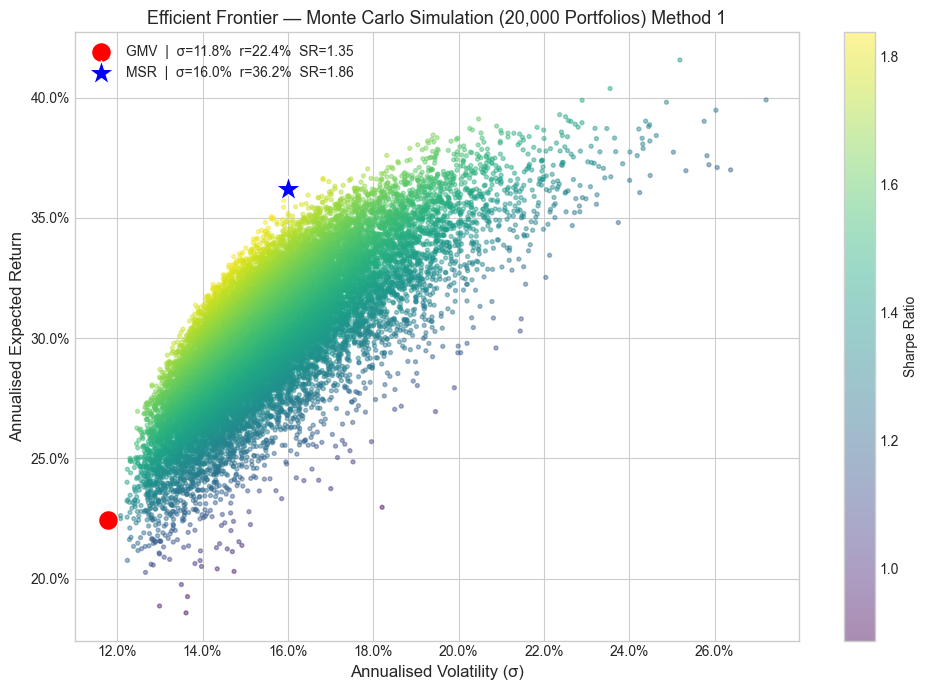

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sim_vol1, sim_ret1, c=sim_shr1, cmap="viridis",
                alpha=0.45, s=8, rasterized=True)
fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

ax.scatter(v_gmv1, r_gmv1, color="red",  marker="o", s=200, zorder=5,
           edgecolors="white", linewidth=0.8,
           label=f"GMV  |  σ={v_gmv1:.1f}%  r={r_gmv1:.1f}%  SR={s_gmv1:.2f}")
ax.scatter(v_msr1, r_msr1, color="blue", marker="*", s=350, zorder=5,
           edgecolors="white", linewidth=0.8,
           label=f"MSR  |  σ={v_msr1:.1f}%  r={r_msr1:.1f}%  SR={s_msr1:.2f}")

ax.set_xlabel("Annualised Volatility (σ)", fontsize=12)
ax.set_ylabel("Annualised Expected Return", fontsize=12)
ax.set_title("Efficient Frontier — Monte Carlo Simulation (20,000 Portfolios) Method 1", fontsize=13)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y}%"))
plt.tight_layout()
plt.show()

### Method 2:

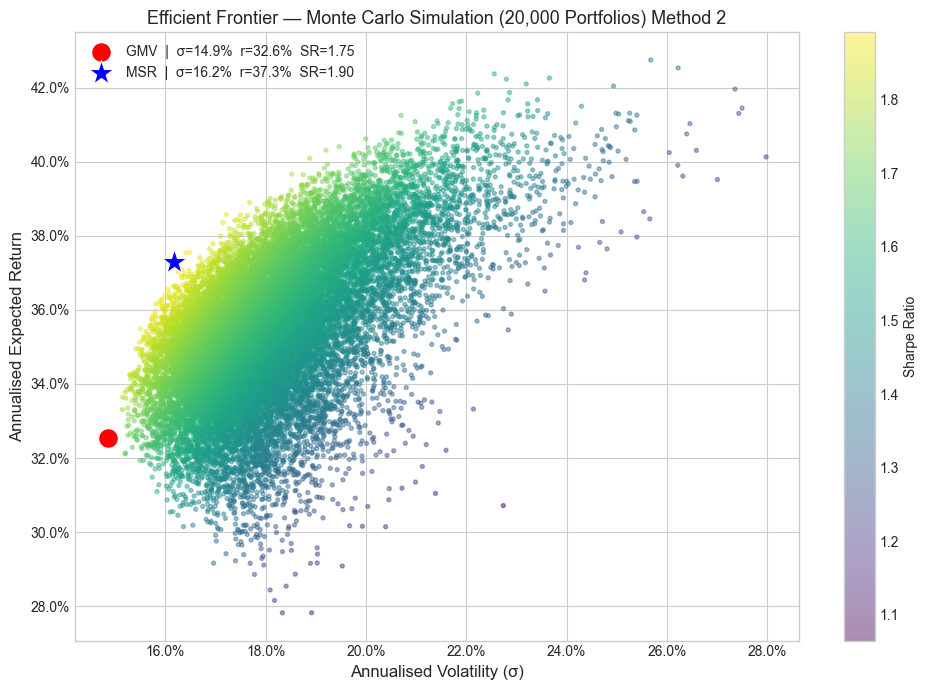

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sim_vol2, sim_ret2, c=sim_shr2, cmap="viridis",
                alpha=0.45, s=8, rasterized=True)
fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

ax.scatter(v_gmv2, r_gmv2, color="red",  marker="o", s=200, zorder=5,
           edgecolors="white", linewidth=0.8,
           label=f"GMV  |  σ={v_gmv2:.1f}%  r={r_gmv2:.1f}%  SR={s_gmv2:.2f}")
ax.scatter(v_msr2, r_msr2, color="blue", marker="*", s=350, zorder=5,
           edgecolors="white", linewidth=0.8,
           label=f"MSR  |  σ={v_msr2:.1f}%  r={r_msr2:.1f}%  SR={s_msr2:.2f}")

ax.set_xlabel("Annualised Volatility (σ)", fontsize=12)
ax.set_ylabel("Annualised Expected Return", fontsize=12)
ax.set_title("Efficient Frontier — Monte Carlo Simulation (20,000 Portfolios) Method 2", fontsize=13)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y}%"))
plt.tight_layout()
plt.show()

## 8. Weight Attribution — GMV vs. Maximum Sharpe

### Method 1:

,Sector,Ann. Return,Ann. Vol,Sharpe,GMV Wt. %,MSR Wt. %
Stock,,,,,,
BHARTIARTL,Telecommunications,34.7%,20.1%,1.40,13.47,39.47
BAJAJ-AUTO,Automobiles,36.7%,24.4%,1.23,5.74,23.44
TRENT,Retail/E-commerce,44.9%,35.0%,1.10,0.00,13.30
ADANIPORTS,Construction/Infra,42.9%,35.8%,1.02,0.00,6.14
NTPC,Energy & Power,31.9%,25.5%,1.00,2.54,7.41
SBIN,Banking & Finance,28.9%,22.8%,0.98,13.26,8.97
HINDALCO,Metals & Mining,29.4%,28.4%,0.80,0.64,1.09
SUNPHARMA,Pharmaceuticals,18.1%,18.5%,0.63,25.49,0.00
HCLTECH,Information Tech,20.3%,22.9%,0.60,11.98,0.19


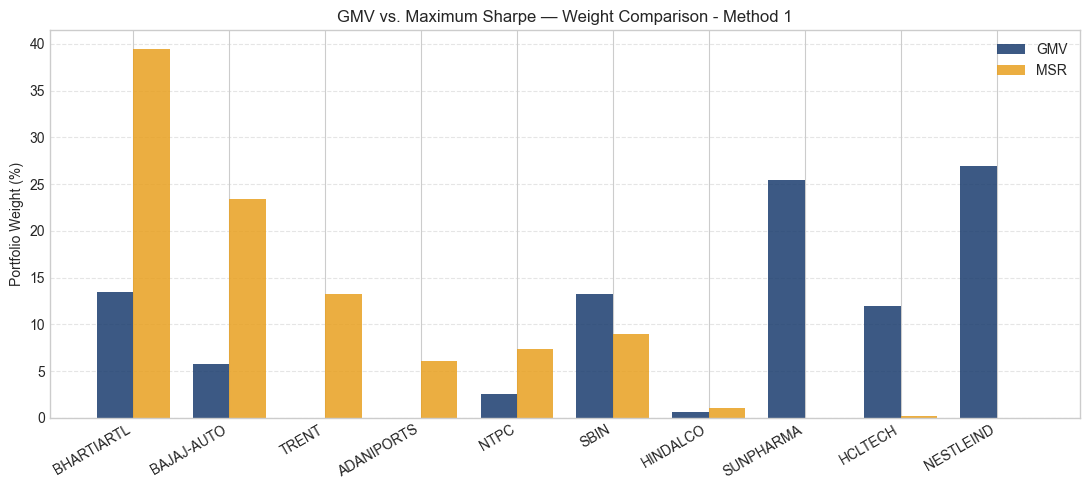

In [26]:
weight_df1 = pd.DataFrame({
    "Stock"      : selected_symbols1,
    "Sector"     : [metrics_df.loc[s, "Category"] for s in selected_symbols1],
    "Ann. Return": [f"{metrics_df.loc[s,'ann_return']:.1f}%" for s in selected_symbols1],
    "Ann. Vol"   : [f"{metrics_df.loc[s,'ann_vol']:.1f}%"    for s in selected_symbols1],
    "Sharpe"     : [f"{metrics_df.loc[s,'sharpe']:.2f}"          for s in selected_symbols1],
    "GMV Wt. %"  : np.round(w_gmv1 * 100, 2),
    "MSR Wt. %"  : np.round(w_msr1 * 100, 2),
})

# Add totals row
totals1 = pd.DataFrame([{
    "Stock":"TOTAL","Sector":"","Ann. Return":"","Ann. Vol":"","Sharpe":"",
    "GMV Wt. %": round(w_gmv1.sum()*100, 2),
    "MSR Wt. %": round(w_msr1.sum()*100, 2),
}])
display(pd.concat([weight_df1, totals1], ignore_index=True).set_index("Stock"))

# Bar chart comparison
x = np.arange(N)
width = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, w_gmv1*100, width, label="GMV", color="#1a3c6e", alpha=0.85)
ax.bar(x + width/2, w_msr1*100, width, label="MSR", color="#e8a020", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(selected_symbols1, rotation=30, ha='right')
ax.set_ylabel("Portfolio Weight (%)")
ax.set_title("GMV vs. Maximum Sharpe — Weight Comparison - Method 1")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Method 2:

,Sector,Ann. Return,Ann. Vol,Sharpe,GMV Wt. %,MSR Wt. %
Stock,,,,,,
BHARTIARTL,Telecommunications,34.7%,20.1%,1.40,33.07,34.95
BAJAJ-AUTO,Automobiles,36.7%,24.4%,1.23,17.30,20.97
TRENT,Retail/E-commerce,44.9%,35.0%,1.10,2.53,12.06
M&M,Automobiles,36.4%,27.4%,1.09,5.59,7.78
INDUSTOWER,Telecommunications,44.7%,35.7%,1.07,0.00,9.56
ADANIPORTS,Construction/Infra,42.9%,35.8%,1.02,0.00,3.92
NTPC,Energy & Power,31.9%,25.5%,1.00,4.92,5.35
SBIN,Banking & Finance,28.9%,22.8%,0.98,17.46,5.42
HINDALCO,Metals & Mining,29.4%,28.4%,0.80,5.70,0.00


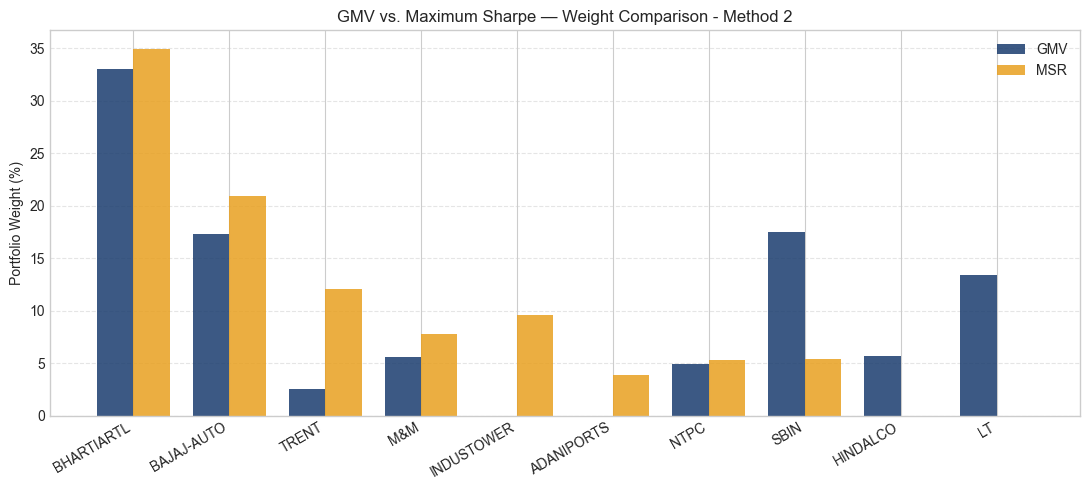

In [27]:
weight_df2 = pd.DataFrame({
    "Stock"      : selected_symbols2,
    "Sector"     : [metrics_df.loc[s, "Category"] for s in selected_symbols2],
    "Ann. Return": [f"{metrics_df.loc[s,'ann_return']:.1f}%" for s in selected_symbols2],
    "Ann. Vol"   : [f"{metrics_df.loc[s,'ann_vol']:.1f}%"    for s in selected_symbols2],
    "Sharpe"     : [f"{metrics_df.loc[s,'sharpe']:.2f}"          for s in selected_symbols2],
    "GMV Wt. %"  : np.round(w_gmv2 * 100, 2),
    "MSR Wt. %"  : np.round(w_msr2 * 100, 2),
})

# Add totals row
totals2 = pd.DataFrame([{
    "Stock":"TOTAL","Sector":"","Ann. Return":"","Ann. Vol":"","Sharpe":"",
    "GMV Wt. %": round(w_gmv2.sum()*100, 2),
    "MSR Wt. %": round(w_msr2.sum()*100, 2),
}])
display(pd.concat([weight_df2, totals2], ignore_index=True).set_index("Stock"))

# Bar chart comparison
x = np.arange(N)
width = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, w_gmv2*100, width, label="GMV", color="#1a3c6e", alpha=0.85)
ax.bar(x + width/2, w_msr2*100, width, label="MSR", color="#e8a020", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(selected_symbols2, rotation=30, ha='right')
ax.set_ylabel("Portfolio Weight (%)")
ax.set_title("GMV vs. Maximum Sharpe — Weight Comparison - Method 2")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Summary & Conclusion

### Selected Portfolio Universe (Top 10 by Annualised Sharpe Ratio - Method 2)

| Ticker | Company | Sector | Ann. Return | Ann. Vol | Sharpe |
|---|---|---|---|---|---|
| BHARTIARTL | Bharti Airtel | Telecommunications | 34.71% | 20.08% | 1.405 |
| BAJAJ-AUTO | Bajaj Auto | Automobiles | 36.67% | 24.45% | 1.234 |
| TRENT | Trent | Retail/E-commerce | 44.95% | 35.00% | 1.098 |
| M&M | Mahindra & Mahindra | Automobiles | 36.41% | 27.42% | 1.091 |
| INDUSTOWER | Indus Towers | Telecommunications | 44.73% | 35.69% | 1.071 |
| ADANIPORTS | Adani Ports | Construction/Infra | 42.94% | 35.75% | 1.019 |
| NTPC | NTPC | Energy & Power | 31.88% | 25.45% | 0.997 |
| SBIN | State Bank of India | Banking & Finance | 28.88% | 22.77% | 0.983 |
| HINDALCO | Hindalco | Metals & Mining | 29.35% | 28.42% | 0.804 |
| LT | Larsen & Toubro | Construction/Infra | 24.38% | 23.34% | 0.766 |

---

### Optimal Portfolio Results

| Metric | Global Min. Variance (GMV) | Maximum Sharpe (MSR) |
|---|---|---|
| **Annualised Return** | 32.55% | 37.30% |
| **Annualised Volatility** | 14.85% | 16.17% |
| **Sharpe Ratio** | 1.7540 | 1.9049 |
| **Risk-Free Rate** | 6.5% | 6.5% |

### Weight Attribution

| Ticker | GMV Weight | MSR Weight |
|---|---|---|
| BHARTIARTL | 33.07% | 34.95% |
| BAJAJ-AUTO | 17.30% | 20.97% |
| TRENT | 2.53% | 12.06% |
| M&M | 5.59% | 7.78% |
| INDUSTOWER | 0.00% | 9.56% |
| ADANIPORTS | 0.00% | 3.92% |
| NTPC | 4.92% | 5.35% |
| SBIN | 17.46% | 5.42% |
| HINDALCO | 5.70% | 0.00% |
| LT | 13.42% | 0.00% |
| **TOTAL** | **100.00%** | **100.00%** |

---

### Key Takeaways

- **Stock Selection:** The top 10 stocks by annualised Sharpe ratio were chosen from the 30-stock NSE universe. Stocks were ranked on `(Annualised Return − 6.5%) / Annualised Volatility`. This rewards high return *and* penalises high risk simultaneously. The resulting basket spans 8 sectors, and the cross-sector correlation heatmap confirms predominantly low-to-moderate pairwise correlations, validating the diversification quality of the selection.

- **GMV Portfolio** minimises portfolio volatility (σ = 14.85%) by distributing weight across lower-volatility anchors: BHARTIARTL (33.07%), SBIN (17.46%), BAJAJ-AUTO (17.30%), and LT (13.42%). INDUSTOWER and ADANIPORTS receive zero weight as their high volatility is not compensated enough to reduce overall portfolio risk.

- **MSR Portfolio** maximises risk-adjusted return (Sharpe = 1.905) by concentrating in the highest-Sharpe names: BHARTIARTL (34.95%), BAJAJ-AUTO (20.97%), TRENT (12.06%), and INDUSTOWER (9.56%). HINDALCO and LT receive zero weight as their lower Sharpe ratios drag down the objective.

- Both portfolios comfortably exceed the 6.5% risk-free rate hurdle.

- An investor can tune their exposure by blending GMV and MSR along the **Capital Market Line** to match their personal risk appetite.